In [1]:
%cd ..
%env
%load_ext autoreload
%autoreload 2

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.datasets.visloc import SatChunkDataset, UAVDataset
from src.evaluation import build_ground_truth, calculate_metrics
from src.retrievers import FAISSRetriever
from src.utils import visualize_embeddings

warnings.filterwarnings("ignore", message=".*invalid escape sequence.*")

NUM_WORKERS = 8
DEVICE = torch.device("cuda")
VISLOC_ROOT = Path(os.environ["VISLOC_ROOT"])
DIFFUSIONSAT_256_CHCKPT = Path(os.environ["DIFFUSIONSAT_256_CHCKPT"])

/root/diffusion-vpr


/root/diffusion-vpr/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
!uv pip install rshf

In [2]:
import open_clip
import torch.nn as nn
from huggingface_hub import PyTorchModelHubMixin, hf_hub_download
from safetensors.torch import load_file
from transformers import PretrainedConfig

# SRC: https://github.com/mvrl/rshf/tree/main/rshf/remoteclip


class RemoteCLIPConfig(PretrainedConfig):
  """
  Configuration class to store the configuration of a `RemoteCLIP` model.

  Arguments:
      model_name: str (default: 'ViT-B-32'). OpenCLIP model architecture name.
  """

  def __init__(self, model_name="ViT-B-32", **kwargs):
    super().__init__(**kwargs)
    self.model_name = model_name

  def from_dict(self, config_dict):  # ty:ignore[invalid-method-override]
    for key, value in config_dict.items():
      setattr(self, key, value)
    return self


class RemoteCLIP(nn.Module, PyTorchModelHubMixin):
  def __init__(self, config: PretrainedConfig | None = None, model_name="ViT-B-32"):
    super().__init__()
    if config is not None:
      if type(config) is dict:
        config = RemoteCLIPConfig().from_dict(config)
      model_name = config.model_name
    self.model, _, self.preprocess = open_clip.create_model_and_transforms(model_name)
    self.tokenizer = open_clip.get_tokenizer(model_name)


checkpoint_path = hf_hub_download("MVRL/remote-clip-vit-base-patch32", "model.safetensors")
state_dict = load_file(checkpoint_path)

model = RemoteCLIP(model_name="ViT-B-32")
model.load_state_dict(state_dict)
model = model.to(DEVICE).eval()

embedder = model.model.visual
preprocess = model.preprocess
tokenizer = model.tokenizer

In [3]:
@torch.inference_mode()
def extract_embeddings(loader: DataLoader) -> tuple[torch.Tensor, list[float], list[float]]:
  embeddings = []
  all_lats = []
  all_lons = []

  for imgs, lats, lons in tqdm(loader, desc="Building embeddings"):
    imgs = imgs.to(DEVICE)
    embs = embedder(imgs)

    embeddings.append(embs.cpu())
    all_lats.extend(lats)
    all_lons.extend(lons)

  embeddings = torch.cat(embeddings, dim=0)
  embeddings = F.normalize(embeddings, p=2, dim=1)

  return embeddings, all_lats, all_lons

In [4]:
FLIGHT_ID = "03"

BATCH_SIZE = 256

CHUNK_PIXELS = 512
CHUNK_STRIDE = 128
MAP_SCALE_FACTOR = 0.25

inference_sat_transforms = preprocess
inference_uav_transforms = preprocess


gallery_dataset = SatChunkDataset(
  VISLOC_ROOT,
  FLIGHT_ID,
  chunk_pixels=CHUNK_PIXELS,
  stride_pixels=CHUNK_STRIDE,
  scale_factor=MAP_SCALE_FACTOR,
  transform=inference_sat_transforms,
)
gallery_loader = DataLoader(
  gallery_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

uav_dataset = UAVDataset(VISLOC_ROOT, FLIGHT_ID, transform=inference_uav_transforms)
uav_loader = DataLoader(uav_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Gallery: {len(gallery_dataset)} satellite chunks")
print(f"Query:   {len(uav_dataset)} UAV images")

Gallery: 2860 satellite chunks
Query:   768 UAV images


In [5]:
gallery_embeddings, _, _ = extract_embeddings(gallery_loader)
query_embeddings, uav_lats, uav_lons = extract_embeddings(uav_loader)

Building embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Building embeddings: 100%|██████████| 3/3 [00:33<00:00, 11.27s/it]


In [6]:
uav_coords = np.stack([uav_lats, uav_lons], axis=1)
ground_truth = build_ground_truth(uav_coords, gallery_dataset.chunk_bboxes)

print(f"{len(ground_truth)} UAV queries, avg {np.mean([len(gt) for gt in ground_truth]):.1f} matching chunks each")

retriever = FAISSRetriever(gallery_embeddings)
distances, preds = retriever.search(query_embeddings, k=10)

metrics = calculate_metrics(preds, ground_truth)

print(metrics)

768 UAV queries, avg 15.9 matching chunks each
{'Recall@1': 0.0703125, 'Recall@5': 0.1796875, 'Recall@10': 0.25390625}


In [ ]:
entry = {
  "model": "MVRL/remote-clip-vit-base-patch32",
  "model_extra": {},
  "dataset": "visloc",
  "dataset_extra": {
    "flight_id": FLIGHT_ID,
    "chunk_pixels": CHUNK_PIXELS,
    "chunk_stride": CHUNK_STRIDE,
    "map_scale_factor": MAP_SCALE_FACTOR,
  },
  "emb_dim": gallery_embeddings.shape[1],
  "n_gallery": len(gallery_dataset),
  "n_query": len(uav_dataset),
  "retriever_type": retriever.type,
  **metrics,
}

entry

{'model': 'MVRL/remote-clip-vit-base-patch32',
 'model_extra': {},
 'dataset': 'visloc',
 'dataset_extra': {'flight_id': '03',
  'chunk_pixels': 512,
  'chunk_stride': 128,
  'map_scale_factor': 0.25},
 'emb_dim': 512,
 'n_gallery': 2860,
 'n_query': 768,
 'retriever_type': 'ip',
 'Recall@1': 0.0703125,
 'Recall@5': 0.1796875,
 'Recall@10': 0.25390625}

In [ ]:
results_path = Path("results/1-baseline-comparison.csv")
results = pd.read_csv(results_path).to_dict(orient="records") if results_path.exists() else []

results.append(entry)

pd.DataFrame(results).sort_values("Recall@1", ascending=False).to_csv(results_path, index=False)

/root/diffusion-vpr/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


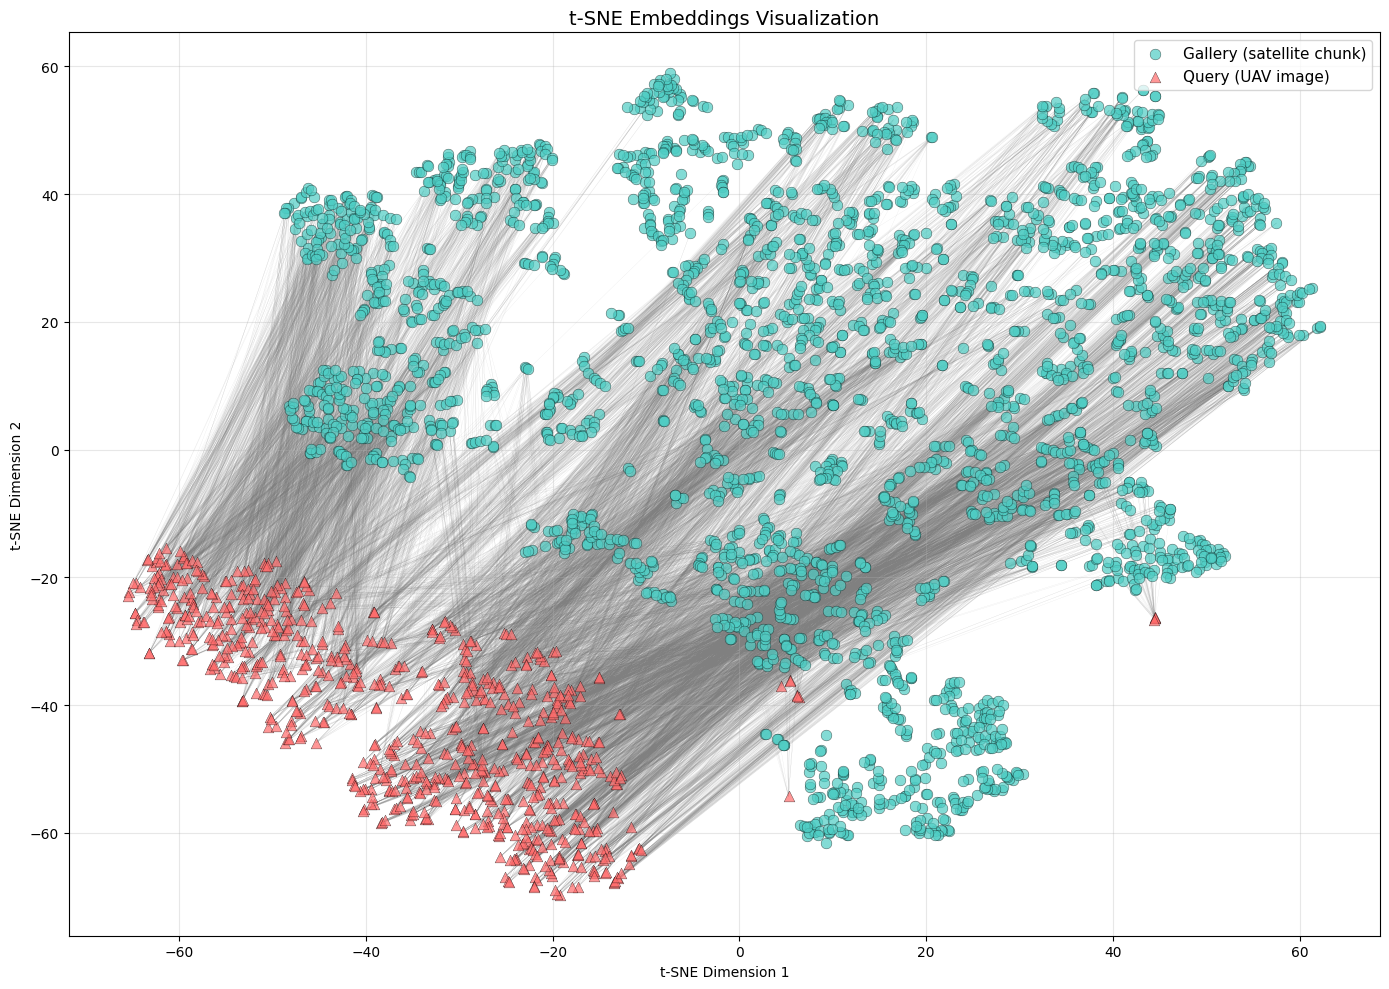

In [8]:
visualize_embeddings(gallery_embeddings, query_embeddings, ground_truth)